# v5 UV-only `mesolve` finite-difference gradient benchmark

This notebook tests whether using QuTiP `mesolve` for UV-pulse time evolution and finite differences for gradients is faster than an exact Frechet-derivative gradient. It intentionally disables clock shelving/unshelving and studies only the UV segment.

Important scope note: the executable benchmark below is an optimistic lower bound for `mesolve` finite differences because it propagates one physical density matrix. The current v5 `active_channel` objective is harder: it needs a reduced process map, i.e. multiple operator-basis evolutions per objective evaluation. A direct `mesolve` active-channel finite-difference test with the shelved operator basis was attempted first and did not complete even the 1-slot case in a practical time window, because it requires evolving non-Hermitian channel-basis operators.

## What `expm_frechet` means

For a piecewise-constant time slot, the Liouville-space propagator is

$$P_k = \exp(\Delta t L_k),$$

where $L_k = L_0 + x_k L_x + y_k L_y$ is the slot Liouvillian. A gradient optimizer needs derivatives such as

$$\partial_{x_k} P_k = \frac{\partial}{\partial x_k}\exp(\Delta t L_k).$$

For non-commuting matrices this is not simply $\Delta t L_x \exp(\Delta t L_k)$. The Frechet derivative of the matrix exponential is the exact first-order response

$$D\exp_A(E)=\left.\frac{d}{d\epsilon}\exp(A+\epsilon E)\right|_{\epsilon=0}.$$

Thus `expm_frechet(dt * L_k, dt * L_x)` gives the exact derivative of the slot propagator with respect to the UV `x` quadrature. This avoids finite-difference noise and gives all control gradients in one forward/backward propagation pass, but each Frechet derivative on a 121 x 121 Liouville matrix is expensive.

## Physical model

- Model line: current v5 calibrated `^171Yb` effective clock-to-Rydberg CZ model.
- Basis: 11 effective states `|01>`, `|0c>`, `|0r>`, `|11>`, `|W_c>`, `|cc>`, `|W_r>`, `|W_cr>`, `|rr>`, `|leak>`, `|loss>`.
- Simulated segment: UV pulse only. Fixed clock shelving and unshelving are disabled by setting `clock_pi_time = 0` and `clock_num_steps = 1`.
- Active shelved probe: the initial state is `( |0c> + |cc> ) / sqrt(2)`, i.e. after ideal clock shelving has already happened.
- Target probe: `( exp(i theta)|0c> - exp(2i theta)|cc> ) / sqrt(2)` with fixed `theta = 0.25` for this runtime test.
- Hamiltonian: v5 drift plus UV controls, `H_k = H_0 + x_k H_x + y_k H_y` in each slot.
- Noise: only Rydberg decay is enabled, with lifetime `T1 = 65 us`; all detuning noise, clock scattering/loss/dephasing, leakage, and blockade jitter are disabled.
- Controls: UV quadratures `(x_k, y_k)` with a flat envelope. Flat envelope is used so small slot counts remain a meaningful gradient test.
- Objective: `1 - <target|rho(T)|target>` for the shelved probe density matrix.
- Compared gradients: exact Liouville Frechet gradient versus central finite difference of the same objective where every objective evaluation is computed by QuTiP `mesolve`.

In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import qutip
from scipy.linalg import expm, expm_frechet

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "neutral_yb").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Run this notebook from inside the repository")
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from neutral_yb.config.yb171_calibration import (
    build_yb171_v5_calibrated_model,
    yb171_experimental_calibration,
    yb171_gate_time_ns_to_dimensionless,
)
from neutral_yb.models.yb171_clock_rydberg_cz_open import Yb171ClockRydbergNoiseConfig
from neutral_yb.optimization.grape import OpenSystemGRAPE
from neutral_yb.optimization.open_system_grape import OpenSystemGRAPEConfig

qutip.settings.core["auto_tidyup"] = False

OMEGA_MAX_HZ = 10e6
GATE_TIME_NS = 240.0
THETA = 0.25
SLOT_COUNTS = (1,)
FINITE_DIFF_STEP = 1e-5
MESOLVE_RTOL = 1e-7
MESOLVE_ATOL = 1e-9

In [2]:
def build_uv_only_decay_model():
    calibration = yb171_experimental_calibration(profile="strict_literature_minimal")
    rydberg_decay = calibration.dimensionless_rate_from_lifetime(
        calibration.rydberg_lifetime_s,
        OMEGA_MAX_HZ,
    )
    model = build_yb171_v5_calibrated_model(
        include_noise=False,
        effective_rabi_hz=OMEGA_MAX_HZ,
        profile="strict_literature_minimal",
    )
    return replace(
        model,
        clock_pi_time=0.0,
        clock_num_steps=1,
        noise=Yb171ClockRydbergNoiseConfig(rydberg_decay_rate=rydberg_decay),
    )


def build_optimizer(num_tslots: int) -> OpenSystemGRAPE:
    return OpenSystemGRAPE(
        model=build_uv_only_decay_model(),
        config=OpenSystemGRAPEConfig(
            num_tslots=int(num_tslots),
            evo_time=yb171_gate_time_ns_to_dimensionless(GATE_TIME_NS, effective_rabi_hz=OMEGA_MAX_HZ),
            max_iter=1,
            num_restarts=1,
            init_pulse_type="ZERO",
            control_smoothness_weight=0.0,
            control_curvature_weight=0.0,
            amplitude_diff_weight=0.0,
            phase_diff_weight=0.0,
            radial_amplitude_bound_weight=0.0,
            control_envelope="FLAT",
            objective_metric="active_channel",
            benchmark_active_channel=False,
        ),
    )


def deterministic_controls(optimizer: OpenSystemGRAPE) -> np.ndarray:
    n = optimizer.config.num_tslots
    grid = np.linspace(0.0, 1.0, n, endpoint=False, dtype=np.float64)
    amp = optimizer.amp_bound * (0.35 + 0.45 * np.sin(np.pi * (grid + 0.2)) ** 2)
    phase = 0.3 + 1.2 * grid
    raw_x = amp * np.cos(phase)
    raw_y = amp * np.sin(phase)
    return np.concatenate([raw_x, raw_y])


def shelved_probe_states(dimension: int) -> tuple[qutip.Qobj, qutip.Qobj]:
    source = np.zeros(dimension, dtype=np.complex128)
    target = np.zeros(dimension, dtype=np.complex128)
    source[1] = 1.0 / np.sqrt(2.0)  # |0c>
    source[5] = 1.0 / np.sqrt(2.0)  # |cc>
    target[1] = np.exp(1j * THETA) / np.sqrt(2.0)
    target[5] = -np.exp(2j * THETA) / np.sqrt(2.0)
    return qutip.Qobj(source.reshape((-1, 1))), qutip.Qobj(target.reshape((-1, 1)))

In [3]:
def unpack_controls(optimizer: OpenSystemGRAPE, variables: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n = optimizer.config.num_tslots
    return np.asarray(variables[:n], dtype=np.float64), np.asarray(variables[n:2*n], dtype=np.float64)


def matrix_to_vec(matrix: np.ndarray) -> np.ndarray:
    return np.asarray(matrix, dtype=np.complex128).reshape(-1, order="F")


def vec_to_matrix(vector: np.ndarray, dimension: int) -> np.ndarray:
    return np.asarray(vector, dtype=np.complex128).reshape((dimension, dimension), order="F")


def probe_fidelity_from_matrix(rho: np.ndarray, target_ket: qutip.Qobj) -> float:
    target = np.asarray(target_ket.full(), dtype=np.complex128)
    projector = target @ target.conj().T
    return float(np.real(np.trace(projector @ rho)))


def exact_frechet_probe_objective_gradient(
    optimizer: OpenSystemGRAPE,
    variables: np.ndarray,
) -> tuple[float, np.ndarray]:
    raw_x, raw_y = unpack_controls(optimizer, variables)
    ctrl_x, ctrl_y = optimizer._apply_control_envelope(raw_x, raw_y)
    source_ket, target_ket = shelved_probe_states(optimizer.dimension)
    rho0 = qutip.ket2dm(source_ket)
    initial_vec = matrix_to_vec(np.asarray(rho0.full(), dtype=np.complex128))
    target_projector = np.asarray(qutip.ket2dm(target_ket).full(), dtype=np.complex128)

    member = optimizer.ensemble_data[0]
    dt = optimizer.config.dt
    propagators = []
    prefix_states = [initial_vec]
    current = initial_vec
    for x_value, y_value in zip(ctrl_x, ctrl_y):
        liouvillian = member["l_d"] + float(x_value) * member["l_x"] + float(y_value) * member["l_y"]
        propagator = expm(dt * liouvillian)
        propagators.append(propagator)
        current = propagator @ current
        prefix_states.append(current)

    final_matrix = vec_to_matrix(prefix_states[-1], optimizer.dimension)
    objective = 1.0 - probe_fidelity_from_matrix(final_matrix, target_ket)

    suffix_propagators = [optimizer.liou_identity for _ in range(optimizer.config.num_tslots)]
    suffix = optimizer.liou_identity
    for index in range(optimizer.config.num_tslots - 1, -1, -1):
        suffix_propagators[index] = suffix
        suffix = suffix @ propagators[index]

    gradient_x = np.zeros(optimizer.config.num_tslots, dtype=np.float64)
    gradient_y = np.zeros(optimizer.config.num_tslots, dtype=np.float64)
    for index, (x_value, y_value) in enumerate(zip(ctrl_x, ctrl_y)):
        liouvillian = member["l_d"] + float(x_value) * member["l_x"] + float(y_value) * member["l_y"]
        dpx = expm_frechet(dt * liouvillian, dt * member["l_x"], compute_expm=False)
        dpy = expm_frechet(dt * liouvillian, dt * member["l_y"], compute_expm=False)
        dvec_x = suffix_propagators[index] @ dpx @ prefix_states[index]
        dvec_y = suffix_propagators[index] @ dpy @ prefix_states[index]
        drho_x = vec_to_matrix(dvec_x, optimizer.dimension)
        drho_y = vec_to_matrix(dvec_y, optimizer.dimension)
        gradient_x[index] = -float(np.real(np.trace(target_projector @ drho_x)))
        gradient_y[index] = -float(np.real(np.trace(target_projector @ drho_y)))

    return float(objective), np.concatenate([gradient_x, gradient_y])

In [4]:
def piecewise_coeff(values: np.ndarray, edges: np.ndarray):
    values = np.asarray(values, dtype=np.float64)
    edges = np.asarray(edges, dtype=np.float64)

    def coeff(t, args=None):
        index = int(np.searchsorted(edges, float(t), side="right") - 1)
        index = min(max(index, 0), values.size - 1)
        return float(values[index])

    return coeff


def mesolve_probe_objective(optimizer: OpenSystemGRAPE, variables: np.ndarray) -> float:
    raw_x, raw_y = unpack_controls(optimizer, variables)
    ctrl_x, ctrl_y = optimizer._apply_control_envelope(raw_x, raw_y)
    source_ket, target_ket = shelved_probe_states(optimizer.dimension)
    rho0 = qutip.ket2dm(source_ket)
    dt = optimizer.config.dt
    edges = np.linspace(0.0, dt * optimizer.config.num_tslots, optimizer.config.num_tslots + 1)
    h_d = optimizer.model.drift_hamiltonian()
    h_x, h_y = optimizer.model.lower_leg_control_hamiltonians()
    hamiltonian = [h_d, [h_x, piecewise_coeff(ctrl_x, edges)], [h_y, piecewise_coeff(ctrl_y, edges)]]
    options = {
        "store_states": True,
        "rtol": MESOLVE_RTOL,
        "atol": MESOLVE_ATOL,
        "nsteps": 20000,
        "progress_bar": "",
    }
    result = qutip.mesolve(hamiltonian, rho0, edges, optimizer.model.collapse_operators(), [], options=options)
    final_matrix = np.asarray(result.states[-1].full(), dtype=np.complex128)
    return float(1.0 - probe_fidelity_from_matrix(final_matrix, target_ket))


def central_finite_difference_gradient(objective, variables: np.ndarray, step: float) -> tuple[float, np.ndarray]:
    gradient = np.zeros_like(variables, dtype=np.float64)
    objective_at_variables = float(objective(variables))
    for index in range(variables.size):
        shifted_plus = np.array(variables, copy=True)
        shifted_minus = np.array(variables, copy=True)
        shifted_plus[index] += step
        shifted_minus[index] -= step
        gradient[index] = (float(objective(shifted_plus)) - float(objective(shifted_minus))) / (2.0 * step)
    return objective_at_variables, gradient


def time_once(callable_object):
    started = time.perf_counter()
    result = callable_object()
    return float(time.perf_counter() - started), result

In [5]:
rows = []
for num_tslots in SLOT_COUNTS:
    optimizer = build_optimizer(num_tslots)
    variables = deterministic_controls(optimizer)

    exact_time_s, (exact_objective, exact_gradient) = time_once(
        lambda: exact_frechet_probe_objective_gradient(optimizer, variables)
    )
    mesolve_objective_time_s, mesolve_objective = time_once(lambda: mesolve_probe_objective(optimizer, variables))
    fd_time_s, (fd_objective, fd_gradient) = time_once(
        lambda: central_finite_difference_gradient(
            lambda candidate: mesolve_probe_objective(optimizer, candidate),
            variables,
            FINITE_DIFF_STEP,
        )
    )
    gradient_error = np.linalg.norm(fd_gradient - exact_gradient)
    gradient_scale = max(1e-15, np.linalg.norm(exact_gradient))
    rows.append(
        {
            "num_tslots": int(num_tslots),
            "num_uv_variables": int(variables.size),
            "mesolve_objective_evaluations_for_central_fd": int(2 * variables.size + 1),
            "exact_frechet_gradient_s": float(exact_time_s),
            "mesolve_single_objective_s": float(mesolve_objective_time_s),
            "mesolve_central_fd_gradient_s": float(fd_time_s),
            "fd_to_exact_runtime_ratio": float(fd_time_s / exact_time_s),
            "exact_objective": float(exact_objective),
            "mesolve_objective": float(mesolve_objective),
            "fd_objective": float(fd_objective),
            "objective_abs_error_mesolve_vs_exact": float(abs(mesolve_objective - exact_objective)),
            "gradient_l2_error": float(gradient_error),
            "gradient_relative_l2_error": float(gradient_error / gradient_scale),
        }
    )
rows

/home/eris/projects/Noise-Tolerant-Quantum-Control-Optimization/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


[{'num_tslots': 1,
  'num_uv_variables': 2,
  'mesolve_objective_evaluations_for_central_fd': 5,
  'exact_frechet_gradient_s': 1.264574797000023,
  'mesolve_single_objective_s': 18.86162177999995,
  'mesolve_central_fd_gradient_s': 143.3611550760006,
  'fd_to_exact_runtime_ratio': 113.36708229208683,
  'exact_objective': 0.5075614603694837,
  'mesolve_objective': 0.5075614605762918,
  'fd_objective': 0.5075614605762918,
  'objective_abs_error_mesolve_vs_exact': 2.0680812617968058e-10,
  'gradient_l2_error': 4.0322434975760367e-07,
  'gradient_relative_l2_error': 1.5957796339322345e-07}]

slots=1, variables=2: exact Frechet 1.265s; mesolve FD 143.361s; ratio 113.37x; single mesolve objective 18.862s; objective error 2.07e-10; gradient rel error 1.60e-07


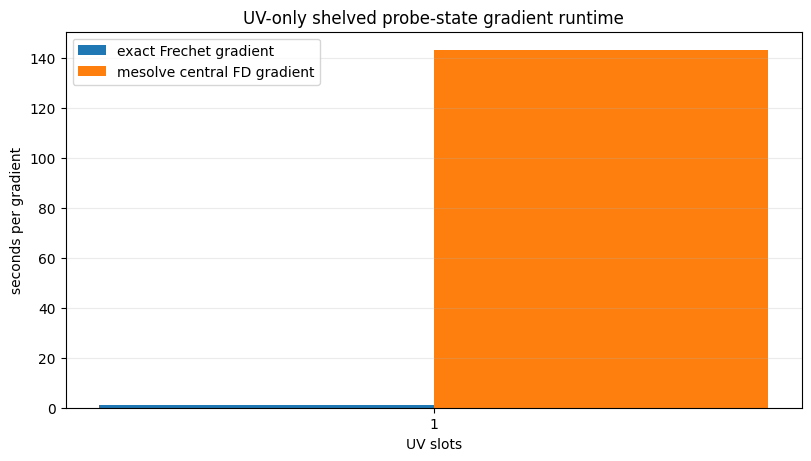

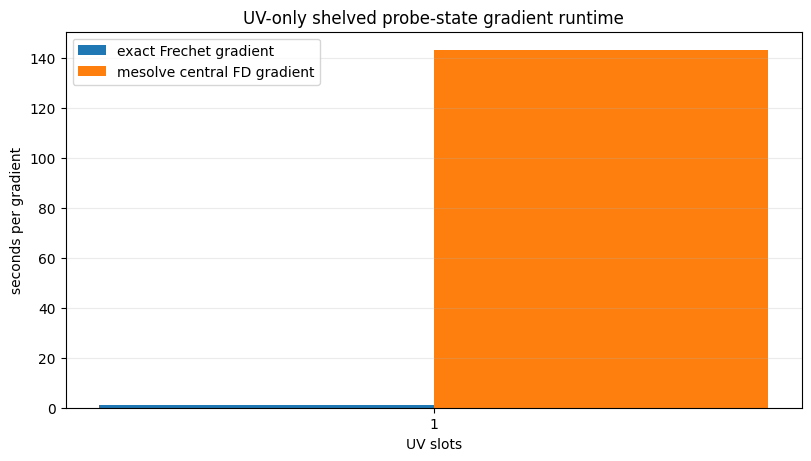

In [6]:
for row in rows:
    print(
        f"slots={row['num_tslots']}, variables={row['num_uv_variables']}: "
        f"exact Frechet {row['exact_frechet_gradient_s']:.3f}s; "
        f"mesolve FD {row['mesolve_central_fd_gradient_s']:.3f}s; "
        f"ratio {row['fd_to_exact_runtime_ratio']:.2f}x; "
        f"single mesolve objective {row['mesolve_single_objective_s']:.3f}s; "
        f"objective error {row['objective_abs_error_mesolve_vs_exact']:.2e}; "
        f"gradient rel error {row['gradient_relative_l2_error']:.2e}"
    )

x = np.arange(len(rows), dtype=np.float64)
labels = [str(row["num_tslots"]) for row in rows]
width = 0.35
fig, ax = plt.subplots(figsize=(8.0, 4.5), constrained_layout=True)
ax.bar(x - width / 2.0, [row["exact_frechet_gradient_s"] for row in rows], width, label="exact Frechet gradient")
ax.bar(x + width / 2.0, [row["mesolve_central_fd_gradient_s"] for row in rows], width, label="mesolve central FD gradient")
ax.set_xticks(x, labels)
ax.set_xlabel("UV slots")
ax.set_ylabel("seconds per gradient")
ax.set_title("UV-only shelved probe-state gradient runtime")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
fig